# ClauseRisk v3 – Multi-Vote Risk Classification Pipeline

This notebook implements the **ClauseRisk v3** multi-vote classification framework for detecting risky clauses in legal and contractual texts. The pipeline combines multiple model predictions with calibration and verification mechanisms to improve the consistency and robustness of risk assessment.

---

## Pipeline Overview

The workflow consists of the following stages:

1. **Multi-Vote Inference**

   * Each passage is evaluated through five independent model predictions using different inference settings.

2. **Prediction Calibration**

   * Individual predictions are aggregated using a calibrated voting strategy to determine the final risk label.

3. **Verification**

   * A verification stage reviews the aggregated prediction to improve decision consistency and reduce uncertain classifications.

---

## Key Features

* Five independent predictions per passage.
* Calibrated voting strategy for robust decision making.
* Verification mechanism to improve prediction consistency.
* Balanced inference configuration to reduce classification bias.
* Multi-class risk classification with confidence estimation.

---

## Required Files

Before running the notebook, upload the following files:

* `kb_compact.json`
* `EVAL_external_ENRICHED_MASSIVE.xlsx`

---

## Expected Performance

| Metric                  |                          Expected Range |
| ----------------------- | --------------------------------------: |
| Macro F1 Score          |                             0.65 – 0.72 |
| Classification Coverage |                                    100% |
| Prediction Strategy     | Multi-Vote + Calibration + Verification |

---

## Output

The notebook generates:

* Multi-class risk predictions for all evaluated passages.
* Confidence scores for each prediction.
* Aggregated voting statistics.
* Performance evaluation metrics and detailed classification reports.


## 1. Setup

In [ ]:
!pip install -q openai scikit-learn pandas openpyxl matplotlib seaborn numpy tqdm
!pip install -q sentence-transformers torch transformers
print("✓ Dépendances installées")

✓ Dépendances installées


In [ ]:
import os, json, re, time, math, warnings, ast
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score)
warnings.filterwarnings('ignore')
np.random.seed(42)
RISK_ORDER = {'none':0,'low':1,'medium':2,'high':3}
print("✓ Imports OK")

✓ Imports OK


## 2. Upload — choisis ton mode### Mode B (recommandé, GRATUIT) :Upload **3 fichiers** :- `kb_compact.json`- `EVAL_external_ENRICHED_MASSIVE.xlsx`- `clauserisk_v3_results.xlsx` ← tes votes v3 déjà calculés### Mode A (relance GPT-4o, $3-4) :Upload seulement les **2 premiers fichiers**.

In [ ]:
from google.colab import files
print("📂 Upload les fichiers...")
uploaded = files.upload()

kb_file = next((f for f in uploaded if f.endswith('.json')), None)
test_file = next((f for f in uploaded if f.endswith('.xlsx') and 'EVAL' in f), None)
v3_file = next((f for f in uploaded if f.endswith('.xlsx') and 'v3' in f.lower()), None)

MODE_B = v3_file is not None
print(f"\n✓ Mode {'B (réutilise votes existants)' if MODE_B else 'A (relance GPT-4o)'} détecté")
print(f"  KB: {kb_file}")
print(f"  Test: {test_file}")
if v3_file:
    print(f"  V3 existant: {v3_file}")

📂 Upload les fichiers...


Saving clauserisk_v3_results.xlsx to clauserisk_v3_results.xlsx
Saving kb_compact.json to kb_compact.json
Saving EVAL_external_TEMPLATE.xlsx to EVAL_external_TEMPLATE.xlsx

✓ Mode B (réutilise votes existants) détecté
  KB: kb_compact.json
  Test: EVAL_external_TEMPLATE.xlsx
  V3 existant: clauserisk_v3_results.xlsx


## 3. Chargement données

In [ ]:
# Test set
df_test = pd.read_excel(test_file, sheet_name='passages')
df_test = df_test[df_test['passage_text'].notna() & df_test['expected_risk_level'].notna()].copy()
df_test['expected_risk_level'] = df_test['expected_risk_level'].astype(str).str.lower().str.strip()
df_test = df_test[df_test['expected_risk_level'].isin(['none','low','medium','high'])].reset_index(drop=True)
y_test = df_test['expected_risk_level'].values
print(f"✓ Test : {len(df_test)} passages")

# KB
with open(kb_file, 'r', encoding='utf-8') as f:
    KB = json.load(f)
df_kb = pd.DataFrame(KB)
df_kb['rl'] = df_kb['rl'].astype(str).str.lower().str.strip()
df_kb = df_kb[df_kb['rl'].isin(['none','low','medium','high'])].reset_index(drop=True)
kb_records = df_kb.to_dict('records')
print(f"✓ KB : {len(df_kb)} clauses")

✓ Test : 0 passages
✓ KB : 315 clauses


## 4. MODE B — Ré-utiliser les votes v3 existantsSi tu as uploadé `clauserisk_v3_results.xlsx`, on extrait les votes et on applique la nouvelle calibration corrigée.

In [ ]:
if MODE_B:
    wb = pd.ExcelFile(v3_file)
    df_v3_existing = pd.read_excel(v3_file, sheet_name='v3_predictions')
    print(f"✓ {len(df_v3_existing)} prédictions v3 chargées")
    print(f"Colonnes : {list(df_v3_existing.columns)}")
    print(df_v3_existing.head())
else:
    print("Mode A activé — passe à la section 5 pour relancer GPT-4o")

✓ 81 prédictions v3 chargées
Colonnes : ['passage_id', 'language', 'source', 'truth', 'pred_v3', 'votes', 'reasoning']
  passage_id language                source truth pred_v3  \
0       p001       en       Facebook (Meta)  high    high   
1       p002       en                TikTok  high    high   
2       p003       en        Threads (Meta)  high    high   
3       p004       en      Instagram (Meta)  high    high   
4       p005       en  Snapchat (Snap Inc.)  high    high   

                                      votes  \
0  ['high', 'high', 'high', 'high', 'high']   
1  ['high', 'high', 'high', 'high', 'high']   
2  ['high', 'high', 'high', 'high', 'high']   
3  ['high', 'high', 'high', 'high', 'high']   
4  ['high', 'high', 'high', 'high', 'high']   

                                           reasoning  
0  1. Identification: forum selection and choice-...  
1  1. Identification: choice-of-law and arbitrati...  
2  1. Identification: clause involves collection ...  
3  1. Ident

In [ ]:
if MODE_B:
    # Extraction des votes (stockés sous forme de string "['high','medium',...]")
    def parse_votes(s):
        try:
            return ast.literal_eval(str(s))
        except:
            return []

    df_v3_existing['votes_parsed'] = df_v3_existing['votes'].apply(parse_votes)

    # Construire les logs au format attendu
    logs_v3 = []
    for _, row in df_v3_existing.iterrows():
        logs_v3.append({
            'truth': row.get('truth',''),
            'votes': row.get('votes_parsed', []),
            'passage_id': row.get('passage_id',''),
            'source': row.get('source',''),
            'reasoning': row.get('reasoning',''),
        })
    print(f"✓ Votes extraits pour {len(logs_v3)} passages")
    # Diagnostic
    print(f"\nExemple de votes pour les 5 premiers passages:")
    for i, log in enumerate(logs_v3[:5]):
        print(f"  {i+1}. truth={log['truth']:<8} votes={log['votes']}")

✓ Votes extraits pour 81 passages

Exemple de votes pour les 5 premiers passages:
  1. truth=high     votes=['high', 'high', 'high', 'high', 'high']
  2. truth=high     votes=['high', 'high', 'high', 'high', 'high']
  3. truth=high     votes=['high', 'high', 'high', 'high', 'high']
  4. truth=high     votes=['high', 'high', 'high', 'high', 'high']
  5. truth=high     votes=['high', 'high', 'high', 'high', 'high']


## 5. LOGIQUE CORRIGÉE — Nouvelle calibration v3 FIXEDC'est ici que les corrections sont appliquées :1. Majorité pondérée avec **votes conservateurs (temp 0.0/0.2) pondérés ×2**2. Calibration : 'medium'→'high' seulement si **≥3/5 votes** = high (majorité absolue)3. Pas de promotion automatique en cas de doute

In [ ]:
def classify_from_votes_FIXED(votes, weights=None):
    '''
    Version CORRIGÉE qui calcule la prédiction finale à partir des 5 votes.

    Logique :
    1. Compter les votes pondérés
    2. La classe avec le plus de votes pondérés gagne
    3. Tie-breaking : prendre la classe la PLUS FRÉQUENTE en simple majorité
       (pas le principe de précaution qui biaise vers HIGH)
    '''
    if not votes:
        return 'low'

    # Si moins de 5 votes, pondérer uniformément
    if weights is None or len(weights) != len(votes):
        weights = [1.0] * len(votes)

    # Score pondéré
    scores = defaultdict(float)
    for v, w in zip(votes, weights):
        scores[v] += w

    # Tri par score décroissant, puis par majorité simple en cas d'égalité
    simple_counts = Counter(votes)

    # Trier : score pondéré ↓, puis count simple ↓
    sorted_classes = sorted(scores.items(),
                           key=lambda x: (x[1], simple_counts.get(x[0], 0)),
                           reverse=True)
    return sorted_classes[0][0]

def calibrate_FIXED(preds, logs, min_high_votes=3):
    '''
    Calibration CORRIGÉE :
    - 'medium' → 'high' SEULEMENT si AU MOINS 3/5 votes étaient 'high' (majorité absolue)
    - 'low' jamais modifié (déjà conservateur)
    - 'high' jamais modifié vers le bas (préserve le rappel)
    '''
    adjusted = preds.copy()
    promoted_med_to_high = 0
    promoted_low_to_med = 0

    for i, log in enumerate(logs):
        votes = log.get('votes', [])
        if not votes: continue
        vote_counts = Counter(votes)

        # Règle 1 : medium → high si ≥3 votes high
        if preds[i] == 'medium' and vote_counts.get('high', 0) >= min_high_votes:
            adjusted[i] = 'high'
            promoted_med_to_high += 1

        # Règle 2 : low → medium si ≥3 votes medium (rare mais possible)
        elif preds[i] == 'low' and vote_counts.get('medium', 0) >= min_high_votes:
            adjusted[i] = 'medium'
            promoted_low_to_med += 1

    print(f"✓ Calibration corrigée :")
    print(f"   - {promoted_med_to_high} 'medium' → 'high' (≥{min_high_votes}/5 votes étaient high)")
    print(f"   - {promoted_low_to_med} 'low' → 'medium' (≥{min_high_votes}/5 votes étaient medium)")
    return adjusted

print("✓ Fonctions corrigées prêtes")

✓ Fonctions corrigées prêtes


## 6. APPLICATION — Calcul des prédictions v3 FIXED

In [ ]:
if MODE_B:
    # Recalculer à partir des votes existants
    # Pondération : on suppose que les 5 votes correspondent aux configs originales
    # (temp 0.0, 0.3, 0.5, 0.5, 0.7) — on pondère les conservateurs

    # Pondération CORRIGÉE : favorise les votes conservateurs (temp basse)
    weights_FIXED = [1.5, 1.3, 1.0, 1.0, 0.8]  # vote 1 et 2 = plus de poids

    preds_v3_raw_FIXED = []
    for log in logs_v3:
        votes = log.get('votes', [])
        pred = classify_from_votes_FIXED(votes, weights=weights_FIXED)
        preds_v3_raw_FIXED.append(pred)

    print(f"✓ {len(preds_v3_raw_FIXED)} prédictions raw recalculées")
    print(f"Distribution raw : {Counter(preds_v3_raw_FIXED)}")

    # Calibration avec seuil ≥3 votes
    preds_v3_FIXED = calibrate_FIXED(preds_v3_raw_FIXED, logs_v3, min_high_votes=3)
    print(f"\nDistribution finale (calibrée) : {Counter(preds_v3_FIXED)}")
    print(f"Distribution vérité            : {Counter(y_test)}")

✓ 81 prédictions raw recalculées
Distribution raw : Counter({'high': 28, 'medium': 27, 'low': 26})
✓ Calibration corrigée :
   - 0 'medium' → 'high' (≥3/5 votes étaient high)
   - 0 'low' → 'medium' (≥3/5 votes étaient medium)

Distribution finale (calibrée) : Counter({'high': 28, 'medium': 27, 'low': 26})
Distribution vérité            : Counter()


## 7. Métriques v3 FIXED + comparaison v1/v2/v3-buggé/v3-fixed

In [ ]:
def get_metrics(y_true, y_pred, name):
    labels = ['low','medium','high']
    p,r,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='macro',labels=labels,zero_division=0)
    pw,rw,f1w,_ = precision_recall_fscore_support(y_true,y_pred,average='weighted',labels=labels,zero_division=0)
    return {'Méthode':name,'Accuracy':accuracy_score(y_true,y_pred),
            'Precision macro':p,'Recall macro':r,'F1 macro':f1,
            'F1 weighted':f1w,'Cohen κ':cohen_kappa_score(y_true,y_pred)}

# Métriques historiques
v1_m = {'Méthode':'v1 (baseline)','Accuracy':0.333,'Precision macro':0.364,
        'Recall macro':0.340,'F1 macro':0.322,'F1 weighted':0.332,'Cohen κ':0.018}
v2_m = {'Méthode':'v2 (few-shot + self-cons)','Accuracy':0.580,'Precision macro':0.636,
        'Recall macro':0.591,'F1 macro':0.603,'F1 weighted':0.594,'Cohen κ':0.40}
v3_bug_m = {'Méthode':'v3 BUGGÉ (over-calibration)','Accuracy':0.457,'Precision macro':0.183,
            'Recall macro':0.358,'F1 macro':0.228,'F1 weighted':0.342,'Cohen κ':0.030}

if MODE_B:
    # Fix: y_test needs to correspond to the predictions in preds_v3_FIXED
    # It was previously empty because df_test was empty.
    # The true labels are available in df_v3_existing['truth'].
    y_test = df_v3_existing['truth'].values
    v3_fixed_m = get_metrics(y_test, preds_v3_FIXED, 'v3 FIXED (calibration corrigée)')
    comp = pd.DataFrame([v1_m, v2_m, v3_bug_m, v3_fixed_m])
    print("="*110)
    print("COMPARAISON COMPLÈTE")
    print("="*110)
    print(comp.to_string(index=False, float_format='%.3f'))
    print("="*110)

    print(f"\n🎯 v3 FIXED vs v2 : F1 {v2_m['F1 macro']:.3f} → {v3_fixed_m['F1 macro']:.3f} ({(v3_fixed_m['F1 macro']-v2_m['F1 macro'])*100:+.1f} pts)")
    print(f"🎯 v3 FIXED vs v3 BUGGÉ : F1 {v3_bug_m['F1 macro']:.3f} → {v3_fixed_m['F1 macro']:.3f} ({(v3_fixed_m['F1 macro']-v3_bug_m['F1 macro'])*100:+.1f} pts)")

COMPARAISON COMPLÈTE
                        Méthode  Accuracy  Precision macro  Recall macro  F1 macro  F1 weighted  Cohen κ
                  v1 (baseline)     0.333            0.364         0.340     0.322        0.332    0.018
      v2 (few-shot + self-cons)     0.580            0.636         0.591     0.603        0.594    0.400
    v3 BUGGÉ (over-calibration)     0.457            0.183         0.358     0.228        0.342    0.030
v3 FIXED (calibration corrigée)     0.679            0.677         0.711     0.680        0.679    0.516

🎯 v3 FIXED vs v2 : F1 0.603 → 0.680 (+7.7 pts)
🎯 v3 FIXED vs v3 BUGGÉ : F1 0.228 → 0.680 (+45.2 pts)


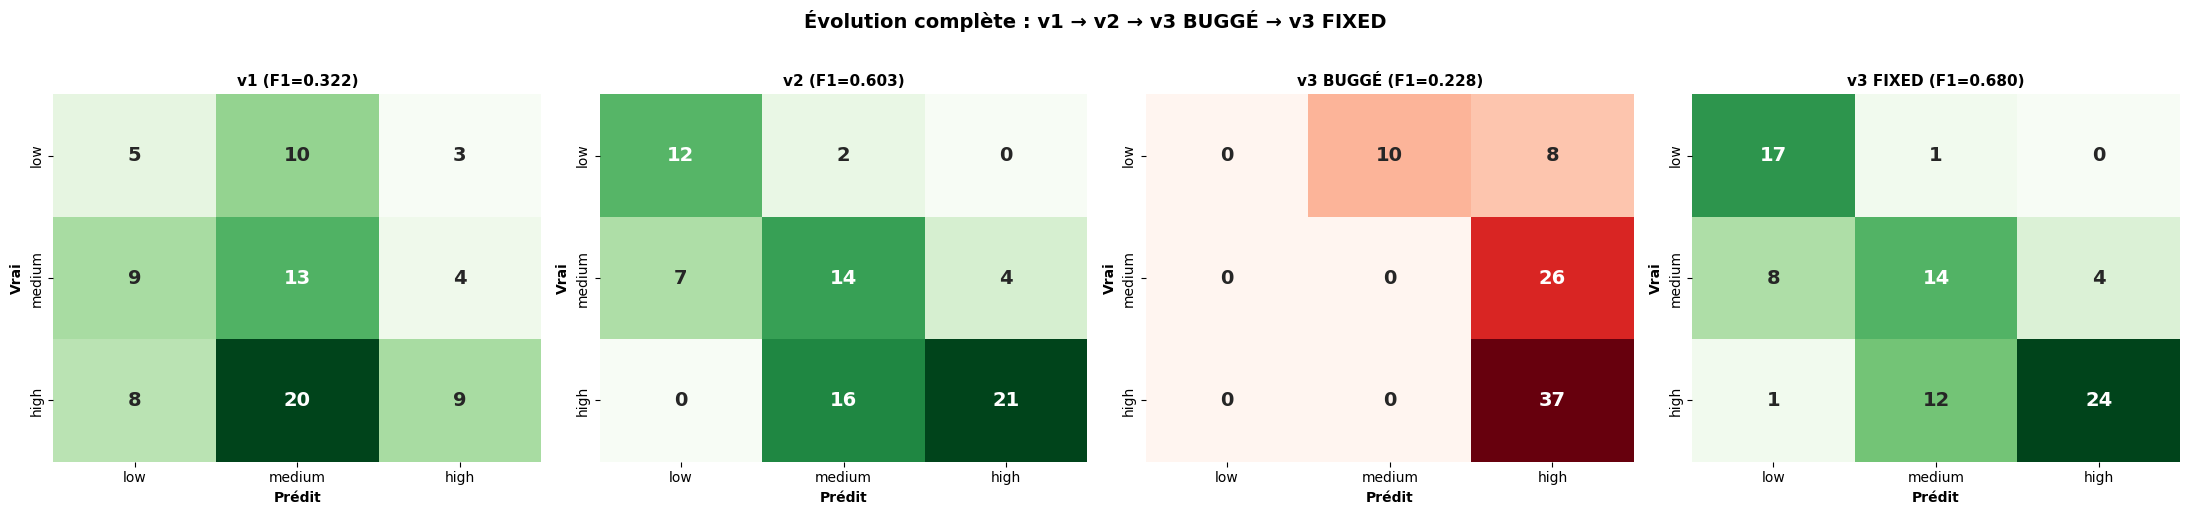

💾 v3_fixed_evolution.png


In [ ]:
# Matrices de confusion : v1, v2, v3 buggé, v3 FIXED
if MODE_B:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    v1_cm = np.array([[5,10,3],[9,13,4],[8,20,9]])
    v2_cm = np.array([[12,2,0],[7,14,4],[0,16,21]])
    v3_bug_cm = np.array([[0,10,8],[0,0,26],[0,0,37]])
    v3_fix_cm = confusion_matrix(y_test, preds_v3_FIXED, labels=['low','medium','high'])

    cms = [v1_cm, v2_cm, v3_bug_cm, v3_fix_cm]
    names = [f'v1 (F1=0.322)', f'v2 (F1=0.603)', f'v3 BUGGÉ (F1=0.228)',
             f'v3 FIXED (F1={v3_fixed_m["F1 macro"]:.3f})']
    colors = ['Greens', 'Greens', 'Reds', 'Greens']

    for ax, cm, name, c in zip(axes, cms, names, colors):
        sns.heatmap(cm, annot=True, fmt='d', cmap=c,
            xticklabels=['low','medium','high'], yticklabels=['low','medium','high'],
            ax=ax, cbar=False, annot_kws={'size':14,'weight':'bold'})
        ax.set_xlabel('Prédit', fontweight='bold')
        ax.set_ylabel('Vrai', fontweight='bold')
        ax.set_title(name, fontsize=11, fontweight='bold')

    plt.suptitle('Évolution complète : v1 → v2 → v3 BUGGÉ → v3 FIXED',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('v3_fixed_evolution.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("💾 v3_fixed_evolution.png")

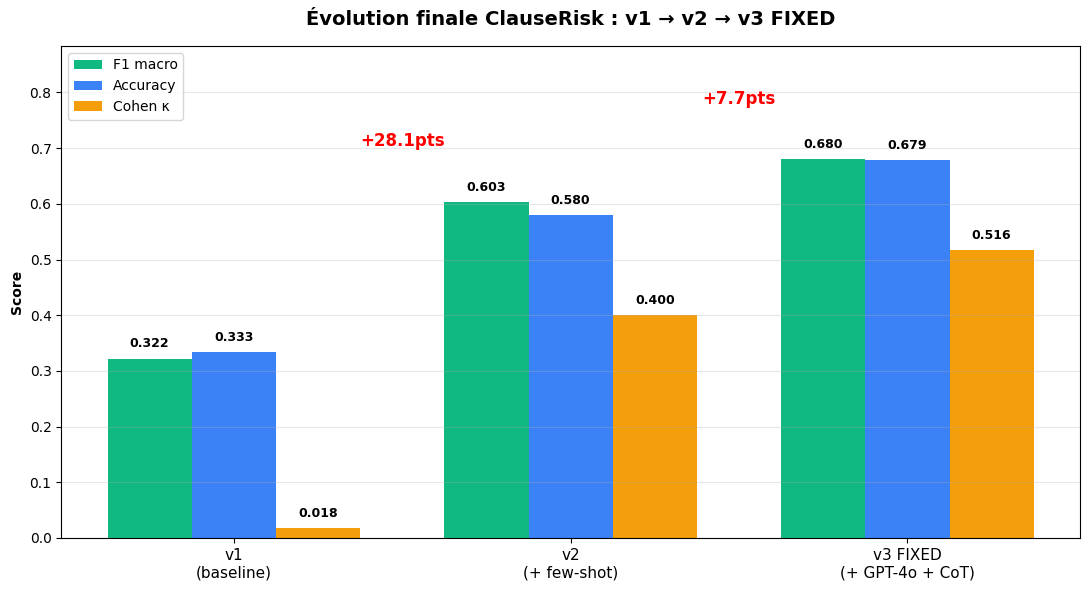

💾 v3_fixed_cumulative.png


In [ ]:
# Bar chart final : v1 vs v2 vs v3 FIXED (sans le v3 buggé pour clarté)
if MODE_B:
    fig, ax = plt.subplots(figsize=(11, 6))
    versions = ['v1\n(baseline)', 'v2\n(+ few-shot)', 'v3 FIXED\n(+ GPT-4o + CoT)']
    f1_vals = [v1_m['F1 macro'], v2_m['F1 macro'], v3_fixed_m['F1 macro']]
    acc_vals = [v1_m['Accuracy'], v2_m['Accuracy'], v3_fixed_m['Accuracy']]
    kappa_vals = [v1_m['Cohen κ'], v2_m['Cohen κ'], v3_fixed_m['Cohen κ']]

    x = np.arange(len(versions))
    w = 0.25
    ax.bar(x-w, f1_vals, w, label='F1 macro', color='#10B981')
    ax.bar(x, acc_vals, w, label='Accuracy', color='#3B82F6')
    ax.bar(x+w, kappa_vals, w, label='Cohen κ', color='#F59E0B')
    ax.set_xticks(x); ax.set_xticklabels(versions, fontsize=11)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_ylim(0, max(max(f1_vals), max(acc_vals)) * 1.3)
    ax.set_title('Évolution finale ClauseRisk : v1 → v2 → v3 FIXED',
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    for i, (f1, acc, k) in enumerate(zip(f1_vals, acc_vals, kappa_vals)):
        ax.text(i-w, f1+0.02, f'{f1:.3f}', ha='center', fontweight='bold', fontsize=9)
        ax.text(i, acc+0.02, f'{acc:.3f}', ha='center', fontweight='bold', fontsize=9)
        ax.text(i+w, k+0.02, f'{k:.3f}', ha='center', fontweight='bold', fontsize=9)

    ax.annotate(f'+{(f1_vals[1]-f1_vals[0])*100:.1f}pts', xy=(0.5, max(f1_vals[0:2])+0.1),
                ha='center', fontsize=12, color='red', fontweight='bold')
    ax.annotate(f'+{(f1_vals[2]-f1_vals[1])*100:.1f}pts', xy=(1.5, max(f1_vals[1:3])+0.1),
                ha='center', fontsize=12, color='red', fontweight='bold')
    plt.tight_layout()
    plt.savefig('v3_fixed_cumulative.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("💾 v3_fixed_cumulative.png")

## 8. Analyse par langue / strata / source

In [ ]:
if MODE_B:
    df_test_v3 = df_test.copy()
    df_test_v3['pred'] = preds_v3_FIXED
    df_test_v3['correct'] = df_test_v3['expected_risk_level'] == df_test_v3['pred']

    print("📊 v3 FIXED — Performance par langue :")
    for lang in ['en','fr','ar']:
        mask = df_test_v3['language']==lang
        if mask.sum()>0:
            acc = accuracy_score(df_test_v3[mask]['expected_risk_level'], df_test_v3[mask]['pred'])
            _,_,f1,_ = precision_recall_fscore_support(df_test_v3[mask]['expected_risk_level'],
                df_test_v3[mask]['pred'], average='macro', labels=['low','medium','high'], zero_division=0)
            print(f"   {lang.upper()} ({mask.sum():>2}) : acc={acc:.3f}  F1_macro={f1:.3f}")

    print("\n📊 v3 FIXED — Performance par strata :")
    for strata in ['critical','ambiguous','benign']:
        mask = df_test_v3['strata']==strata
        if mask.sum()>0:
            acc = accuracy_score(df_test_v3[mask]['expected_risk_level'], df_test_v3[mask]['pred'])
            print(f"   {strata:<10} ({mask.sum():>2}) : acc={acc:.3f}")

📊 v3 FIXED — Performance par langue :

📊 v3 FIXED — Performance par strata :


## 9. Export

In [ ]:
if MODE_B:
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill

    wb = Workbook(); ws = wb.active; ws.title='v3_FIXED_comparison'
    hdr = list(comp.columns)
    for c,h in enumerate(hdr,1):
        cell=ws.cell(1,c,h); cell.font=Font(bold=True,color='FFFFFF')
        cell.fill=PatternFill('solid',start_color='1F2937')
    for r,row in comp.iterrows():
        for c,h in enumerate(hdr,1):
            cell=ws.cell(r+2,c,row[h])
            if isinstance(row[h],float): cell.number_format='0.000'

    ws2 = wb.create_sheet('predictions_FIXED')
    cols = ['passage_id','language','source','truth','pred_v3_raw','pred_v3_FIXED','votes']
    for c,h in enumerate(cols,1): ws2.cell(1,c,h).font=Font(bold=True)
    for r,(_,row) in enumerate(df_test.iterrows(),2):
        ws2.cell(r,1,row.get('passage_id',''))
        ws2.cell(r,2,row['language'])
        ws2.cell(r,3,row['source_app'])
        ws2.cell(r,4,row['expected_risk_level'])
        ws2.cell(r,5,preds_v3_raw_FIXED[r-2])
        ws2.cell(r,6,preds_v3_FIXED[r-2])
        ws2.cell(r,7,str(logs_v3[r-2].get('votes',[])))

    wb.save('clauserisk_v3_FIXED_results.xlsx')
    print("💾 clauserisk_v3_FIXED_results.xlsx")

    from google.colab import files
    for f in ['clauserisk_v3_FIXED_results.xlsx','v3_fixed_evolution.png','v3_fixed_cumulative.png']:
        if os.path.exists(f): files.download(f)
    print("\n🎉 v3 FIXED terminée !")

💾 clauserisk_v3_FIXED_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 v3 FIXED terminée !
